<a href="https://colab.research.google.com/github/SweetlinN/flower_classification_model_cnn/blob/main/Cnn_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tensorflow

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Dense,Dropout, Flatten

In [ ]:
dirs = os.listdir("images")

In [ ]:
count = 0
dirs = os.listdir("images/")
for dir in dirs:
  files = list(os.listdir('images/'+dir))
  print(  dir +' Folder has '+ str(len(files)) + ' images')
  count = count + len(files)
print( 'images Folder has '+ str(count) + ' images')

rose Folder has 784 images
tulip Folder has 984 images
daisy Folder has 764 images
sunflower Folder has 733 images
.ipynb_checkpoints Folder has 0 images
dandelion Folder has 1052 images
images Folder has 4317 images


In [ ]:
# load images into Arrays as Dataset

In [ ]:
base_dir = "images/"
img_size = 180
batch = 32

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory( base_dir,
                                                       seed = 123,
                                                        validation_split=0.2,
                                                        subset = 'training',
                                                        batch_size = batch,
                                                        image_size = (img_size,img_size))


Found 4317 files belonging to 5 classes.
Using 3454 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory( base_dir,
                                                       seed = 123,
                                                        validation_split=0.2,
                                                        subset = 'validation',
                                                        batch_size = batch,
                                                        image_size = (img_size,img_size))

Found 4317 files belonging to 5 classes.
Using 863 files for validation.


In [ ]:
flower_names = train_ds.class_names

In [ ]:
flower_names

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

In [ ]:
import matplotlib.pyplot as plt

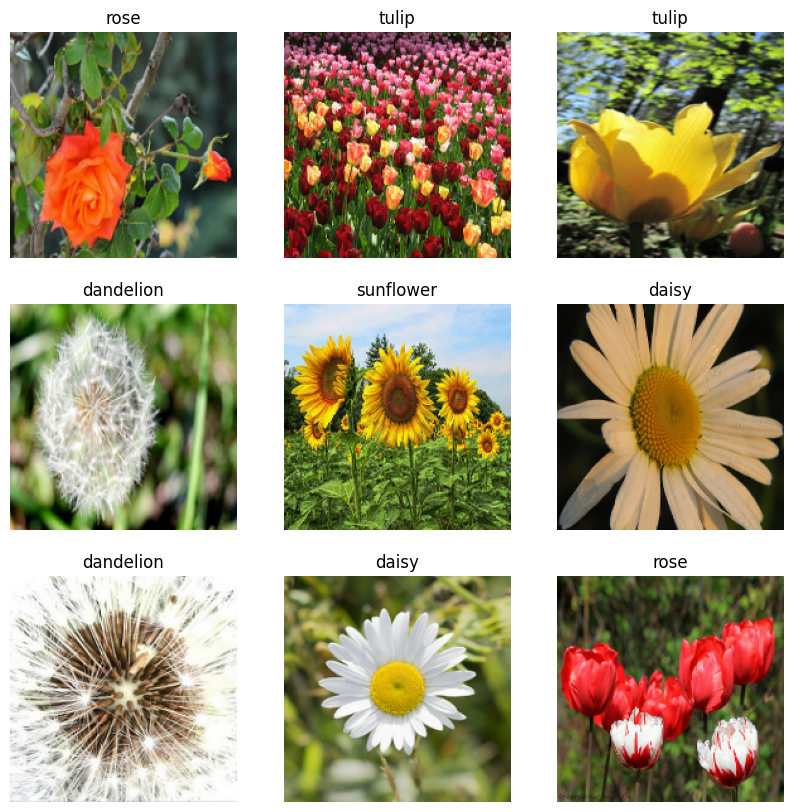

In [ ]:
i = 0
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
  for i in range(9):
    plt.subplot(3,3, i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(flower_names[labels[i]])
    plt.axis('off')


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)

In [ ]:
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

In [ ]:
# DATA AUGMENTATION

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal", input_shape = (img_size,img_size,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


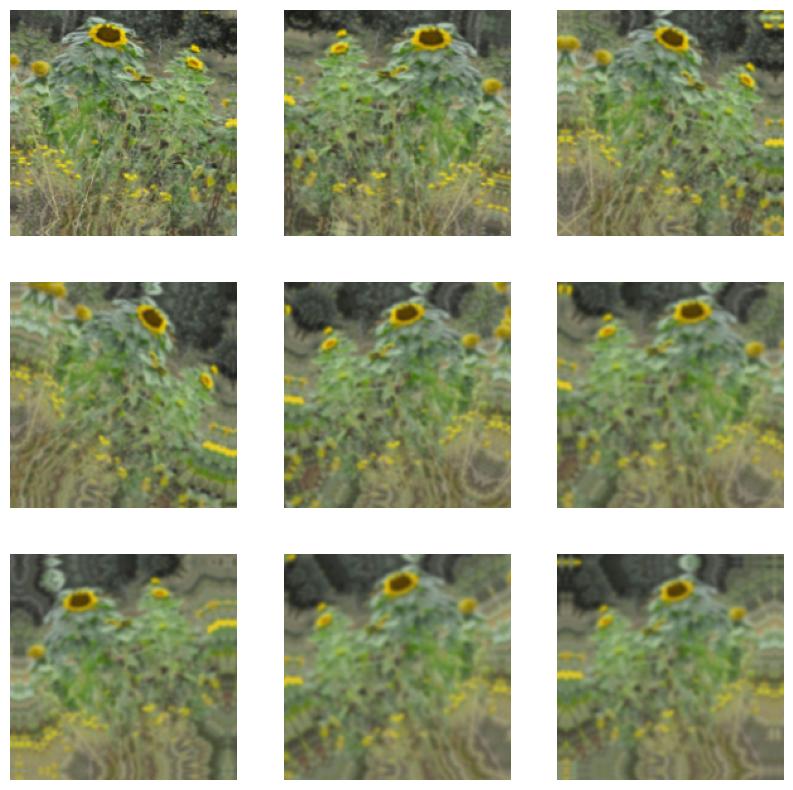

In [ ]:
i = 0
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        images = data_augmentation(images)
        plt.subplot(3,3, i+1)
        plt.imshow(images[0].numpy().astype('uint8'))
        plt.axis('off')


In [ ]:
# model creation

In [ ]:
model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(5)
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = model.fit(train_ds, epochs=15, validation_data=val_ds)

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.4291 - loss: 1.3525 - val_accuracy: 0.5203 - val_loss: 1.1064
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5808 - loss: 1.0669 - val_accuracy: 0.6222 - val_loss: 0.9723
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6277 - loss: 0.9719 - val_accuracy: 0.6454 - val_loss: 0.9162
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6558 - loss: 0.9084 - val_accuracy: 0.6443 - val_loss: 0.9339
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6743 - loss: 0.8579 - val_accuracy: 0.6593 - val_loss: 0.8642
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6948 - loss: 0.8061 - val_accuracy: 0.6628 - val_loss: 0.8626
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7015 - loss: 0.7688 - val_accuracy: 0.6871 - val_loss: 0.8487
Epoch 8/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7166 - loss: 0.7431 - val_accu

In [ ]:
def classify_images(image_path):
    input_image = tf.keras.utils.load_img(image_path, target_size=(180,180))
    input_image_array = tf.keras.utils.img_to_array(input_image)
    input_image_exp_dim = tf.expand_dims(input_image_array,0)

    predictions = model.predict(input_image_exp_dim)
    result = tf.nn.softmax(predictions[0])
    outcome = 'The Image belongs to ' + flower_names[np.argmax(result)] + ' with a score of '+ str(np.max(result)*100)
    return outcome

In [ ]:
classify_images('Sample/sunflower.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


'The Image belongs to sunflower with a score of 99.530716'

In [ ]:
model.save('Flower_Recog_Model.h5')